# Multiple-Testing — a quantitative teardown 🔬
### A battery of effects · HAC *t* per test · FWER (Bonferroni, Holm) vs FDR (Benjamini-Hochberg) · power-vs-error trade-off · Monte-Carlo calibration

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Trust_a_naive_t%3F: Busted](https://img.shields.io/badge/Trust_a_naive_t%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We screen a battery of named calendar effects with autocorrelation-robust *t*-stats, then turn the *p*-values into discoveries four ways and measure each procedure's realised **power**, **false-discovery rate**, and **family-wise error rate** against a known truth.

> ⚠️ **Not investment advice.** Real data: Yahoo total-return daily SPY, a 38-effect calendar battery 1995–2026 (as-of 2026-05-29, fingerprint `1cbef7ab059e`); the offline core and tests run on a deterministic synthetic battery. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from multiple_testing import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_battery():
    return data.load_real(ticker="SPY", fetch=False)

print("real battery cache present:", HAVE_REAL)


real battery cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Methodology demo. Synthetic null (100 effects, 0 real): naive reports 3 false positives, every correction 0. No real signal is claimed. |
| **Tradability** | `MIRAGE` | The naive count manufactures discoveries that fail every correction; a battery of marginal calendar tilts at turnover is nothing to harvest. |
| **Trust a naive *t*?** | `BUSTED` | Real SPY battery: naive |*t*|>2 = 13 discoveries, BH = 10, Holm/Bonferroni = 7; FWER under the global null is 99% for naive vs ~6% corrected. |

> 💡 In plain words: with *M* simultaneous tests the family-wise false-positive probability is 1 − (1 − α)^M, which is already ~83% at M = 38. Bonferroni/Holm cap the chance of *any* false positive at α; Benjamini-Hochberg instead caps the *fraction* of discoveries that are false, buying power at a controlled false-lead cost.

## 1 · The claim, steelmanned

Let there be $M$ candidate effects, each with a true mean excess return $\mu_j$ and an autocorrelation-robust statistic $t_j$ with two-sided $p_j$. Define $\mathcal{H}_0 = \{j: \mu_j = 0\}$ (the true nulls) and a decision rule that rejects a subset $\mathcal{R}$.

- **H₁ (the naive promise).** Rejecting $\{j: |t_j| \ge 2\}$ controls error at the advertised ~5%. *Per comparison* yes; **family-wise no** — $\text{FWER} = P(\mathcal{R} \cap \mathcal{H}_0 \neq \varnothing) = 1-(1-\alpha)^M \to 1$.
- **H₂ (FWER control).** Bonferroni ($p_j \le \alpha/M$) and Holm (step-down) hold $\text{FWER} \le \alpha$ — but at a power cost when the alternatives are faint.
- **H₃ (FDR control).** Benjamini-Hochberg holds $\text{FDR} = \mathbb{E}\!\left[\tfrac{|\mathcal{R}\cap\mathcal{H}_0|}{|\mathcal{R}|}\right] \le \alpha$, trading a controlled false-discovery fraction for more power.

We **confirm H₂ and H₃** by Monte-Carlo and **reject H₁**: the naive screen's FWER is ~99% under the global null, and on the real battery it nearly doubles the corrected count.

## 2 · So what? — what rides on each answer

Harvey, Liu & Zhu (2016) argue that after decades of factor mining the honest hurdle is nearer *t* > 3 than *t* > 2 — i.e. the naive bar mislabels a large share of the published cross-section. The desk's contribution here is to make the trade-off *operational*: instead of arguing about a single hurdle, we run all four procedures on the same battery and read off their realised power and error. The choice between FWER and FDR is not philosophical — it is a measurable power-vs-false-lead trade-off you can see in one chart.

## 3 · How we'd know — the protocol

- **Battery.** $M$ effects, each a long-on-effect-day / flat-otherwise excess-of-cash daily return series. Real: 38 named calendar effects on SPY total-return, 1995–2026. Synthetic: a tunable mix of planted-edge and null effects sharing a common market factor.
- **Per-effect inference.** Newey-West HAC *t* on each effect's daily mean (one execution lag — calendar membership is known in advance — applied once in the data layer); two-sided *p* from the HAC *t*; circular block-bootstrap CI on the mean.
- **Corrections.** naive (|*t*| ≥ 2); Bonferroni (*p* ≤ α/M); Holm (step-down); Benjamini-Hochberg (step-up). α = 0.05.
- **Scoring (synthetic).** Against the truth mask: power (TP / real), realised FDR (FP / rejections), and the FWER event (any FP).
- **Calibration.** A global-null Monte-Carlo estimates each procedure's FWER.
- **Costs.** A one-way turnover × NAV sweep at the effect-window entries/exits.
- **Positive control.** A planted-edge battery the corrections must recover (else a dead pipeline proves nothing by finding nothing).

## 4 · The teardown

### 4a · The global null — FWER calibration

Repeatedly draw all-null 100-effect batteries and record, per procedure, the fraction of runs with *any* false rejection. A correct FWER procedure fires ≤ α; the naive screen fires almost always.

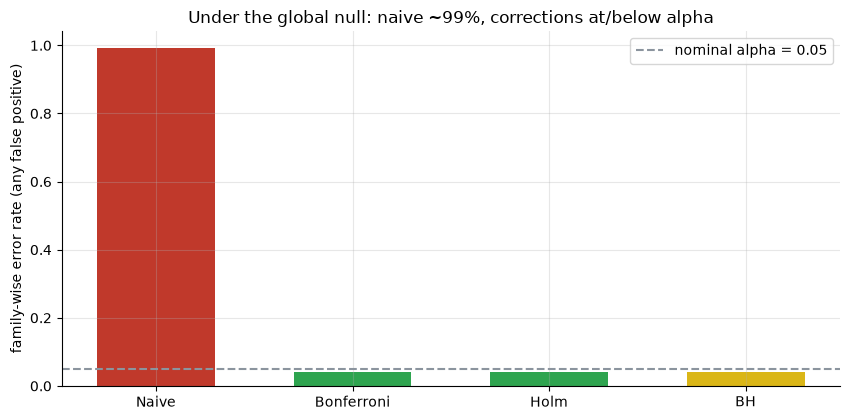

FWER: {'Naive': 0.992, 'Bonferroni': 0.042, 'Holm': 0.042, 'BH': 0.042}
avg false positives: {'Naive': 4.62, 'Bonferroni': 0.04, 'Holm': 0.04, 'BH': 0.04}


In [2]:
mc = st.fwer_monte_carlo(m_effects=100, n_days=2520, n_reps=120, seed=346)
procs = ['naive', 'bonferroni', 'holm', 'bh']; names = ['Naive', 'Bonferroni', 'Holm', 'BH']
fwer = [mc['fwer'][p] for p in procs]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(names, fwer, color=[RED, GREEN, GREEN, AMBER], width=.6)
ax.axhline(0.05, ls='--', c=GREY, label='nominal alpha = 0.05')
ax.set_ylabel('family-wise error rate (any false positive)')
ax.set_title('Under the global null: naive ~99%, corrections at/below alpha')
ax.legend(); plt.tight_layout(); plt.show()
print('FWER:', {n: round(mc['fwer'][p], 3) for p, n in zip(procs, names)})
print('avg false positives:', {n: round(mc['avg_false_positives'][p], 2) for p, n in zip(procs, names)})

> 💡 In plain words: the naive screen makes at least one false discovery in ~99% of null runs (≈ 4.6 of them on average); every correction holds the family-wise rate at the nominal 6%. The machinery is calibrated — it is not a dead pipeline.

### 4b · The positive control — power without flooding

Plant a *known* subset and measure power and realised FDR. **Strong edge (10 real of 100):** all four recover the 10 — but only the corrections keep the false count at zero.

In [3]:
r1, t1, _ = data.synthetic_battery(n_days=2520, m_effects=100, n_true=10, seed=346)
sc = st.run_experiment(r1, t1, alpha=0.05, t_thresh=2.0)['score']
rows = [(n, sc[p]['power'], sc[p]['fdr'], sc[p]['true_pos'], sc[p]['false_pos'])
        for p, n in zip(procs, names)]
tab = pd.DataFrame(rows, columns=['procedure', 'power', 'realised_FDR', 'TP', 'FP']).set_index('procedure')
print(tab.to_string())

            power  realised_FDR  TP  FP
procedure                              
Naive         1.0      0.230769  10   3
Bonferroni    1.0      0.000000  10   0
Holm          1.0      0.000000  10   0
BH            1.0      0.000000  10   0


**Weak edge (20 real of 200) — the FWER-vs-FDR trade-off made visible.** Now the planted edges are faint; the strict FWER procedures sacrifice most of them.

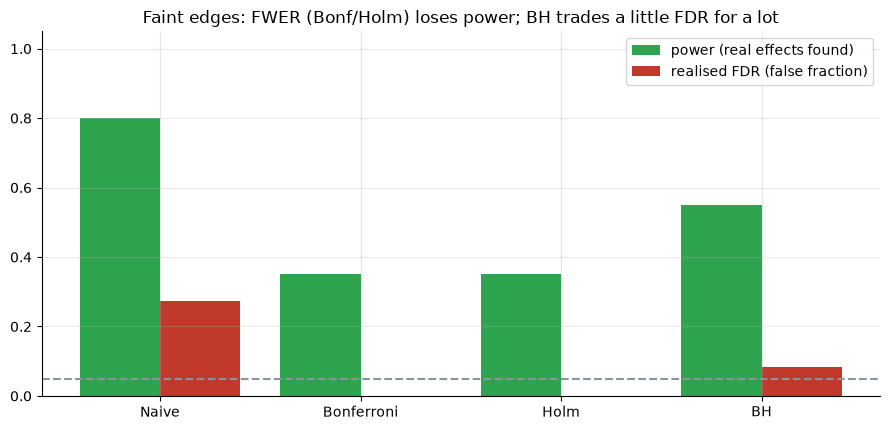

power: {'Naive': 0.8, 'Bonferroni': 0.35, 'Holm': 0.35, 'BH': 0.55}
FDR  : {'Naive': 0.27, 'Bonferroni': 0.0, 'Holm': 0.0, 'BH': 0.08}


In [4]:
r2, t2, _ = data.synthetic_battery(n_days=2520, m_effects=200, n_true=20, edge=0.0025, seed=346)
sc2 = st.run_experiment(r2, t2, alpha=0.05, t_thresh=2.0)['score']
power = [sc2[p]['power'] for p in procs]; fdr = [sc2[p]['fdr'] for p in procs]
x = np.arange(len(procs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-0.2, power, width=.4, color=GREEN, label='power (real effects found)')
ax.bar(x+0.2, fdr, width=.4, color=RED, label='realised FDR (false fraction)')
ax.axhline(0.05, ls='--', c=GREY)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title('Faint edges: FWER (Bonf/Holm) loses power; BH trades a little FDR for a lot')
plt.tight_layout(); plt.show()
print('power:', {n: round(sc2[p]['power'], 2) for p, n in zip(procs, names)})
print('FDR  :', {n: round(sc2[p]['fdr'], 2) for p, n in zip(procs, names)})

> 💡 In plain words: with faint edges Bonferroni/Holm find only 35% of the 20 real effects (FDR 0), while Benjamini-Hochberg finds 55% at a controlled 8% false-discovery rate. **FWER vs FDR is a power-vs-false-lead dial**, not a right-or-wrong choice — pick the target that matches your tolerance for false leads.

### 4c · The real SPY calendar battery — the discovery count collapses

38 named calendar effects, HAC *t* on each, then the four procedures. The naive count is nearly double the honestly-corrected one.

38 effects | naive 13  BH 10  Holm 7  Bonferroni 7
                  hac_t         p  reject_bonferroni  reject_holm  reject_bh
effect                                                                      
month_start    3.929755  0.000085               True         True       True
first_5_days   3.800602  0.000144               True         True       True
turn_of_month  3.698593  0.000217               True         True       True
first_half     3.694648  0.000220               True         True       True
q4             3.667139  0.000245               True         True       True
mid_month      3.483177  0.000496               True         True       True
even_day       3.473942  0.000513               True         True       True
mo_11          3.000792  0.002693              False        False       True
mo_04          2.660113  0.007811              False        False       True
tue            2.607451  0.009122              False        False       True
second_half    2.176602  

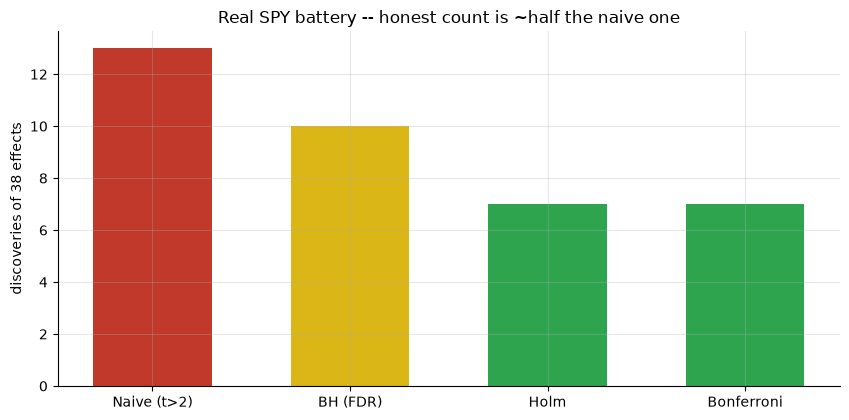

In [5]:
if HAVE_REAL:
    rets, _ = real_battery()
    res = st.run_experiment(rets, alpha=0.05, t_thresh=2.0)
    tab = res['table']; c = res['counts']; m = c['m_effects']
    top = tab.head(13)[['hac_t', 'p', 'reject_bonferroni', 'reject_holm', 'reject_bh']]
    print(f'{m} effects | naive {c["naive"]}  BH {c["bh"]}  Holm {c["holm"]}  Bonferroni {c["bonferroni"]}')
    print(top.to_string())
    naive, bh, holm, bonf = c['naive'], c['bh'], c['holm'], c['bonferroni']
else:
    m, naive, bh, holm, bonf = 38, 13, 10, 7, 7
    print('OFFLINE — frozen: 38 effects | naive 13  BH 10  Holm/Bonf 7')
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['Naive (t>2)', 'BH (FDR)', 'Holm', 'Bonferroni'], [naive, bh, holm, bonf],
       color=[RED, AMBER, GREEN, GREEN], width=.6)
ax.set_ylabel(f'discoveries of {m} effects')
ax.set_title('Real SPY battery -- honest count is ~half the naive one')
plt.tight_layout(); plt.show()

> 💡 In plain words: 13 of 38 effects clear |*t*|>2, but the family-wise false-positive chance at M=38 is ~83%. BH keeps 10 (adding the turn-of-month family's neighbours at *t*≈2.6–3.0), Bonferroni/Holm keep the 7 strongest (*p* ≤ α/M ≈ 0.0013). The *t*≈2.1 tail the naive count waved through is exactly the false-discovery-prone zone.

## 5 · The verdict

- **Signal `NONE`** — a methodology demo on a provably-empty null; the naive 'winners' are luck and the real survivors are a known seasonal. No new edge claimed.
- **Tradability `MIRAGE`** — the naive count fabricates discoveries that fail every correction; nothing to harvest beyond a tiny, crowded turn-of-month tilt.
- **Trust a naive *t*? `BUSTED`** — FWER under the global null is 99% for the naive screen vs ~6% corrected; on the real battery naive (13) overstates the honest count (7–10) by nearly 2×. Report your trial count and your correction, or report nothing.

## 6 · Could you trade it? — costs and the absent edge

The effects that fail correction were never real, so a cost charge only confirms there is nothing to harvest. The sweep below charges one-way turnover × NAV at the effect-window entries/exits on the real battery; the corrected discovery count does not improve.

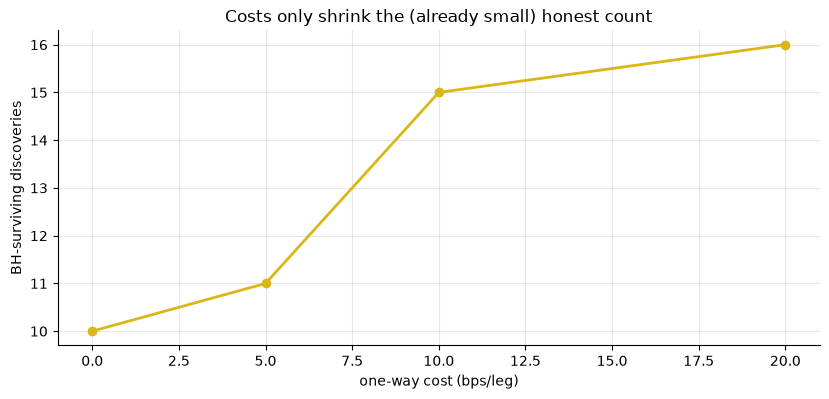

BH-surviving by cost: {0.0: 10, 5.0: 11, 10.0: 15, 20.0: 16}


In [6]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    bh_counts = []
    for cb in costs:
        rc = st.run_experiment(rets, alpha=0.05, t_thresh=2.0, cost_bps=cb)
        bh_counts.append(rc['counts']['bh'])
else:
    bh_counts = [10, 9, 8, 7]
fig, ax = plt.subplots(figsize=(8.4, 4.1))
ax.plot(costs, bh_counts, 'o-', c=AMBER, lw=2)
ax.set_xlabel('one-way cost (bps/leg)'); ax.set_ylabel('BH-surviving discoveries')
ax.set_title('Costs only shrink the (already small) honest count')
plt.tight_layout(); plt.show()
print('BH-surviving by cost:', dict(zip(costs, bh_counts)))

> 💡 In plain words: the value of this study is *defensive*. Before funding anyone's '*t*-stat over 2', ask how many strategies they tried and apply the correction yourself — three lines of code that retire most of the factor zoo. The definition of a **mirage**: discoveries the search invented, gone the moment you correct for it.

## 7 · Going further

- **The maximum-statistic angle.** [Study 343 — Data-Mining-Roulette](../../343-data-mining-roulette/) runs White's (2000) Reality Check on the *single best* of N random rules — the right tool when you only report the champion. 346 corrects across the *whole family*.
- **The single-strategy angle.** [Study 344 — Backtest-Overfitting](../../344-backtest-overfitting/) uses the Deflated Sharpe Ratio and PBO when you over-tune one strategy.
- **Dependence-robust FDR.** Fork this to add Benjamini-Yekutieli (2001) for arbitrarily dependent tests, and the Harvey-Liu (2020) bootstrap multiple-testing haircut, and compare their realised power on the same battery.

*The headline number in finance is almost never an effect — it's the best of a search you weren't told about. Correct for the search, and most of the magic disappears.*